In [2]:
import pandas as pd
meta = pd.read_csv("/home/gwisniewski/myLLF/Speech-Representations/speech-accent-archive/speakers_all.csv") 
meta.head()

,age,age_onset,birthplace,filename,native_language,sex,speakerid,country,file_missing?,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,24.0,12.0,"koussi, senegal",balanta,balanta,male,788,senegal,True,NaN,NaN,NaN
1,18.0,10.0,"buea, cameroon",cameroon,cameroon,male,1953,cameroon,True,NaN,NaN,NaN
2,48.0,8.0,"hong, adamawa, nigeria",fulfulde,fulfulde,male,1037,nigeria,True,NaN,NaN,NaN
3,42.0,42.0,"port-au-prince, haiti",haitian,haitian,male,1165,haiti,True,NaN,NaN,NaN
4,40.0,35.0,"port-au-prince, haiti",haitian,haitian,male,1166,haiti,True,NaN,NaN,NaN


Chargement des données...
Fusion avec les métadonnées (via filename)...

 STATISTIQUES DES DISTANCES
                      mean        std   count
type_paire                                   
Genre Différent  15.358533  12.169328  529526
Même Genre       15.251777  13.350007  548108


/tmp/ipykernel_388819/1086589465.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type_paire', y=0, palette="husl")



Graphique sauvegardé : gender_analysis_layer_19.png


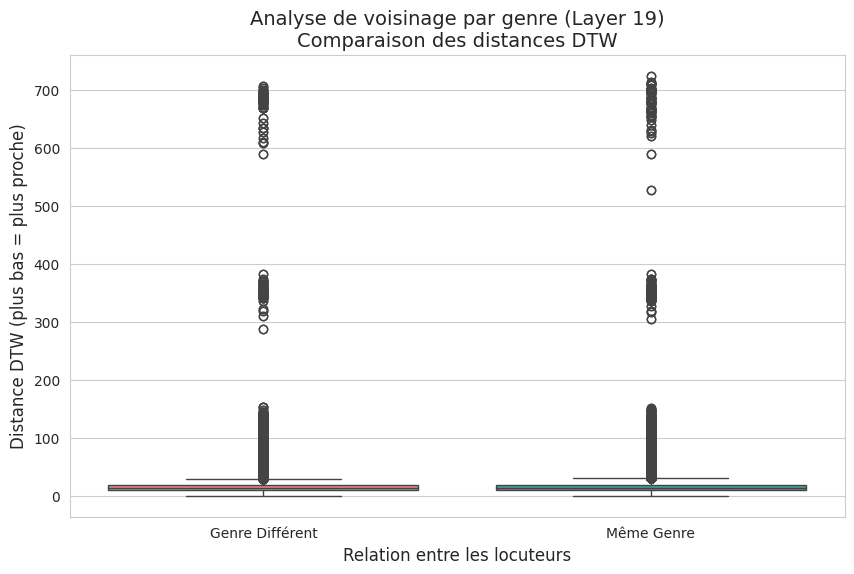

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Configuration
DISTANCES_FILE = "/home/gwisniewski/myLLF/Speech-Representations/nour/experiments/gender_exp_arabic/distances/word_distances_xlsr53_layer_19.pkl"
METADATA_FILE = "/home/gwisniewski/myLLF/Speech-Representations/speech-accent-archive/speakers_all.csv"
OUTPUT_IMAGE = "gender_analysis_layer_19.png"

def analyze_gender():
    print("Chargement des données...")
    # Charger les distances
    df_dist = pd.read_pickle(DISTANCES_FILE)
    
    # Charger les métadonnées (si c'est un CSV)
    # Si c'est un Excel, utilise pd.read_excel(METADATA_FILE)
    df_meta = pd.read_csv(METADATA_FILE) 

    # --- NETTOYAGE ---
    # On passe tout en minuscule pour éviter les problèmes "Arabic1" vs "arabic1"
    df_meta['filename'] = df_meta['filename'].astype(str).str.lower().str.strip()
    df_meta['sex'] = df_meta['sex'].astype(str).str.lower().str.strip()
    
    df_dist['speaker_x'] = df_dist['speaker_x'].astype(str).str.lower().str.strip()
    df_dist['speaker_y'] = df_dist['speaker_y'].astype(str).str.lower().str.strip()

    # --- FUSION (MERGE) ---
    print("Fusion avec les métadonnées (via filename)...")
    
    # On prépare un petit tableau de correspondance filename -> sex
    meta_subset = df_meta[['filename', 'sex']].drop_duplicates()

    # Fusion pour le premier locuteur (x)
    df = df_dist.merge(meta_subset, left_on='speaker_x', right_on='filename')
    df = df.rename(columns={'sex': 'gender_x'}).drop(columns=['filename'])

    # Fusion pour le second locuteur (y)
    df = df.merge(meta_subset, left_on='speaker_y', right_on='filename')
    df = df.rename(columns={'sex': 'gender_y'}).drop(columns=['filename'])

    # --- FILTRAGE ---
    # On enlève les lignes où le locuteur est comparé à lui-même (distance = 0)
    df = df[df['speaker_x'] != df['speaker_y']]

    # On crée la catégorie de comparaison
    df['type_paire'] = df.apply(
        lambda r: 'Même Genre' if r['gender_x'] == r['gender_y'] else 'Genre Différent', 
        axis=1
    )

    # --- RÉSULTATS ---
    print("\n" + "="*30)
    print(" STATISTIQUES DES DISTANCES")
    print("="*30)
    # La colonne de distance dans ton fichier s'appelle '0'
    stats = df.groupby('type_paire')[0].agg(['mean', 'std', 'count'])
    print(stats)

    # --- VISUALISATION ---
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Boxplot pour voir la distribution
    sns.boxplot(data=df, x='type_paire', y=0, palette="husl")
    
    plt.title(f"Analyse de voisinage par genre (Layer 19)\nComparaison des distances DTW", fontsize=14)
    plt.xlabel("Relation entre les locuteurs", fontsize=12)
    plt.ylabel("Distance DTW (plus bas = plus proche)", fontsize=12)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nGraphique sauvegardé : {OUTPUT_IMAGE}")
    plt.show()

if __name__ == "__main__":
    analyze_gender()

In [11]:
import pandas as pd
import numpy as np
import os


def run_knn_analysis():
    # 1. Chargement des distances
    if not os.path.exists(DISTANCES_FILE):
        print(f"Erreur : Le fichier {DISTANCES_FILE} est introuvable.")
        return
    
    print("Chargement des distances...")
    df_dist = pd.read_pickle(DISTANCES_FILE)
    
    # 2. Chargement des métadonnées
    print("Chargement des métadonnées...")
    df_meta = pd.read_csv(METADATA_FILE) 

    # Nettoyage des noms pour la fusion (Merge)
    df_meta['filename'] = df_meta['filename'].astype(str).str.lower().str.strip()
    df_meta['sex'] = df_meta['sex'].astype(str).str.lower().str.strip()
    
    df_dist['speaker_x'] = df_dist['speaker_x'].astype(str).str.lower().str.strip()
    df_dist['speaker_y'] = df_dist['speaker_y'].astype(str).str.lower().str.strip()

    # 3. Fusion des genres (Merge)
    meta_subset = df_meta[['filename', 'sex']].drop_duplicates()
    
    # Récupérer genre du locuteur X
    df = df_dist.merge(meta_subset, left_on='speaker_x', right_on='filename')
    df = df.rename(columns={'sex': 'gender_x'}).drop(columns=['filename'])

    # Récupérer genre du locuteur Y
    df = df.merge(meta_subset, left_on='speaker_y', right_on='filename')
    df = df.rename(columns={'sex': 'gender_y'}).drop(columns=['filename'])

    # Supprimer les auto-comparaisons (Distance 0 avec soi-même)
    df = df[df['speaker_x'] != df['speaker_y']]

    # 4. Sélection d'un locuteur au hasard
    all_speakers = df['speaker_x'].unique()
    target_speaker = np.random.choice(all_speakers)
    target_gender = df[df['speaker_x'] == target_speaker]['gender_x'].iloc[0]

    # 5. Recherche des K plus proches voisins
    # On trie par la colonne '0' qui contient la distance DTW
    neighbors = df[df['speaker_x'] == target_speaker].sort_values(by=0).head(K_NEIGHBORS)

    # 6. Affichage des résultats
    print("\n" + "="*60)
    print(f"ANALYSE DE VOISINAGE (K={K_NEIGHBORS})")
    print(f"Locuteur cible : {target_speaker}")
    print(f"Genre cible    : {target_gender.upper()}")
    print("="*60)
    print(f"{'Rang':<5} | {'Voisin (ID)':<20} | {'Genre':<10} | {'Distance DTW':<10}")
    print("-"*60)

    count_same_gender = 0
    for i, (idx, row) in enumerate(neighbors.iterrows(), 1):
        is_same = row['gender_y'] == target_gender
        if is_same: count_same_gender += 1
        
        indicator = "✅" if is_same else "❌"
        print(f"#{i:<4} | {row['speaker_y']:<20} | {row['gender_y']:<10} | {row[0]:.4f} {indicator}")

    print("-"*60)
    purity = (count_same_gender / K_NEIGHBORS) * 100
    print(f"SCORE DE PURETÉ : {purity}% des voisins sont du même genre.")
    print("="*60)


In [ ]:
METADATA_FILE = "/home/gwisniewski/myLLF/Speech-Representations/speech-accent-archive/speakers_all.csv"
K_NEIGHBORS = 50  # Nombre de voisins à afficher

DISTANCES_FILE = "/home/gwisniewski/myLLF/Speech-Representations/nour/experiments/gender_exp_arabic/distances/word_distances_xlsr53_layer_19.pkl"

run_knn_analysis()

Chargement des distances...
Chargement des métadonnées...

ANALYSE DE VOISINAGE (K=50)
Locuteur cible : arabic51
Genre cible    : MALE
Rang  | Voisin (ID)          | Genre      | Distance DTW
------------------------------------------------------------
#1    | arabic54             | male       | 1.0929 ✅
#2    | arabic85             | female     | 1.1495 ❌
#3    | arabic16             | male       | 1.2435 ✅
#4    | arabic52             | female     | 1.2567 ❌
#5    | arabic70             | male       | 1.3011 ✅
#6    | arabic77             | female     | 1.3032 ❌
#7    | arabic98             | female     | 1.3053 ❌
#8    | arabic5              | female     | 1.3431 ❌
#9    | arabic76             | male       | 1.3554 ✅
#10   | arabic17             | male       | 1.3730 ✅
#11   | arabic8              | male       | 1.4415 ✅
#12   | arabic10             | male       | 1.4449 ✅
#13   | arabic36             | male       | 1.4530 ✅
#14   | arabic15             | male       | 1.4589 ✅
#15  

In [12]:
METADATA_FILE = "/home/gwisniewski/myLLF/Speech-Representations/speech-accent-archive/speakers_all.csv"
K_NEIGHBORS = 50  # Nombre de voisins à afficher

DISTANCES_FILE = "/home/gwisniewski/myLLF/Speech-Representations/nour/experiments/gender_exp_arabic/distances/word_distances_xlsr53_layer_19_normalize.pkl"


run_knn_analysis()

Chargement des distances...
Chargement des métadonnées...

ANALYSE DE VOISINAGE (K=50)
Locuteur cible : arabic65
Genre cible    : FEMALE
Rang  | Voisin (ID)          | Genre      | Distance DTW
------------------------------------------------------------
#1    | arabic2              | male       | 5.1510 ❌
#2    | arabic81             | male       | 5.2323 ❌
#3    | arabic100            | female     | 5.3017 ✅
#4    | arabic2              | male       | 5.3246 ❌
#5    | arabic18             | male       | 5.3279 ❌
#6    | arabic55             | male       | 5.7519 ❌
#7    | arabic78             | female     | 5.7647 ✅
#8    | arabic85             | female     | 5.9470 ✅
#9    | arabic34             | female     | 5.9962 ✅
#10   | arabic30             | female     | 6.0145 ✅
#11   | arabic23             | male       | 6.0154 ❌
#12   | arabic86             | male       | 6.1477 ❌
#13   | arabic77             | female     | 6.2620 ✅
#14   | arabic6              | male       | 6.3010 ❌
#15

In [ ]:
METADATA_FILE = "/home/gwisniewski/myLLF/Speech-Representations/speech-accent-archive/speakers_all.csv"
K_NEIGHBORS = 50  # Nombre de voisins à afficher
DISTANCES_FILE = "/home/gwisniewski/myLLF/Speech-Representations/nour/experiments/gender_exp_arabic/distances/word_distances_xlsr53_layer_24.pkl"

run_knn_analysis()

Chargement des distances...
Chargement des métadonnées...

ANALYSE DE VOISINAGE (K=50)
Locuteur cible : arabic97
Genre cible    : FEMALE
Rang  | Voisin (ID)          | Genre      | Distance DTW
------------------------------------------------------------
#1    | arabic74             | male       | 0.0001 ❌
#2    | arabic16             | male       | 0.0001 ❌
#3    | arabic8              | male       | 0.0001 ❌
#4    | arabic14             | male       | 0.0002 ❌
#5    | arabic42             | male       | 0.0002 ❌
#6    | arabic27             | male       | 0.0002 ❌
#7    | arabic85             | female     | 0.0002 ✅
#8    | arabic36             | male       | 0.0002 ❌
#9    | arabic73             | female     | 0.0002 ✅
#10   | arabic34             | female     | 0.0002 ✅
#11   | arabic50             | male       | 0.0002 ❌
#12   | arabic37             | male       | 0.0002 ❌
#13   | arabic62             | male       | 0.0002 ❌
#14   | arabic68             | male       | 0.0002 ❌
#15

In [14]:
DISTANCES_FILE = "/home/gwisniewski/myLLF/Speech-Representations/nour/experiments/gender_exp_arabic/distances/word_distances_xlsr53_layer_24_normalize.pkl"
run_knn_analysis()

Chargement des distances...
Chargement des métadonnées...

ANALYSE DE VOISINAGE (K=50)
Locuteur cible : arabic29
Genre cible    : MALE
Rang  | Voisin (ID)          | Genre      | Distance DTW
------------------------------------------------------------
#1    | arabic6              | male       | 1.6420 ✅
#2    | arabic100            | female     | 1.8837 ❌
#3    | arabic17             | male       | 1.8903 ✅
#4    | arabic71             | female     | 1.9134 ❌
#5    | arabic89             | female     | 1.9384 ❌
#6    | arabic15             | male       | 1.9649 ✅
#7    | arabic79             | female     | 2.0769 ❌
#8    | arabic10             | male       | 2.1277 ✅
#9    | arabic62             | male       | 2.1357 ✅
#10   | arabic63             | female     | 2.1514 ❌
#11   | arabic57             | female     | 2.2280 ❌
#12   | arabic98             | female     | 2.2499 ❌
#13   | arabic14             | male       | 2.2618 ✅
#14   | arabic67             | male       | 2.2822 ✅
#15  

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
# Chemins vers tes dossiers de résultats (à adapter)
PATH_NORMAL = "distances/normal/" 
PATH_NORMALIZED = "distances/normalized/"
# METADATA_FILE = "ton_fichier_metadata.csv"
K = 10 # Nombre de voisins pour le calcul de pureté

def get_layer_purity(folder_path, df_meta):
    results = []
    # On cherche tous les fichiers .pkl dans le dossier
    files = sorted(glob.glob(os.path.join(folder_path, "*.pkl")))
    
    if not files:
        return None

    # Préparation meta
    meta = df_meta[['filename', 'sex']].drop_duplicates()
    meta['filename'] = meta['filename'].astype(str).str.lower().str.strip()
    meta['sex'] = meta['sex'].astype(str).str.lower().str.strip()

    for f in files:
        # Extraire le numéro de la couche depuis le nom du fichier
        # On suppose un nom comme "...layer_11.pkl"
        layer_num = int(f.split('_layer_')[-1].split('.')[0])
        
        df_dist = pd.read_pickle(f)
        df_dist['speaker_x'] = df_dist['speaker_x'].astype(str).str.lower().str.strip()
        df_dist['speaker_y'] = df_dist['speaker_y'].astype(str).str.lower().str.strip()

        # Fusionner les genres
        df = df_dist.merge(meta, left_on='speaker_x', right_on='filename').rename(columns={'sex': 'gender_x'})
        df = df.merge(meta, left_on='speaker_y', right_on='filename').rename(columns={'sex': 'gender_y'})
        df = df[df['speaker_x'] != df['speaker_y']] # Enlever auto-comparaison

        # Calcul de la pureté moyenne pour cette couche
        purities = []
        for speaker in df['speaker_x'].unique():
            speaker_data = df[df['speaker_x'] == speaker]
            target_gender = speaker_data['gender_x'].iloc[0]
            
            # Prendre les K plus proches voisins (colonne '0' = distance)
            neighbors = speaker_data.sort_values(by=0).head(K)
            purity = (neighbors['gender_y'] == target_gender).mean()
            purities.append(purity)
        
        mean_purity = np.mean(purities)
        results.append({'layer': layer_num, 'purity': mean_purity})
        print(f"Layer {layer_num:02d} terminée. Pureté : {mean_purity:.2%}")
        
    return pd.DataFrame(results).sort_values('layer')

# --- EXÉCUTION ---
df_meta = pd.read_csv(METADATA_FILE)

print("Analyse des couches NORMALES...")
res_normal = get_layer_purity(PATH_NORMAL, df_meta)

print("\nAnalyse des couches NORMALISÉES...")
res_normalized = get_layer_purity(PATH_NORMALIZED, df_meta)

# --- VISUALISATION ---
plt.figure(figsize=(12, 6))
if res_normal is not None:
    plt.plot(res_normal['layer'], res_normal['purity'], marker='o', label='Originale', linewidth=2)
if res_normalized is not None:
    plt.plot(res_normalized['layer'], res_normalized['purity'], marker='s', label='Normalisée (Z-score)', linewidth=2)

# Ligne du hasard (Baseline)
# À ajuster selon tes stats (si 50% hommes / 50% femmes, le hasard est à 0.5)
plt.axhline(y=0.5, color='r', linestyle='--', label='Hasard (50%)')

plt.title(f"Évolution de la pureté du genre par couche (K={K})", fontsize=14)
plt.xlabel("Numéro de la couche (Layer)", fontsize=12)
plt.ylabel("Pureté moyenne (Accuracy KNN)", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("comparison_layers_purity.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'ton_fichier_metadata.csv'

In [10]:
import pandas as pd

# 1. Charger le fichier

df_meta = pd.read_csv(METADATA_FILE)

# 2. Nettoyage des textes pour éviter les erreurs de casse ou d'espaces
df_meta['native_language'] = df_meta['native_language'].astype(str).str.lower().str.strip()
df_meta['sex'] = df_meta['sex'].astype(str).str.lower().str.strip()

# 3. Filtrer uniquement sur les locuteurs dont la langue maternelle est l'arabe
df_arabic = df_meta[df_meta['native_language'] == 'arabic']
# df_arabic=df_meta

# 4. Calculer les statistiques par genre
stats_genre = df_arabic['sex'].value_counts()
total = len(df_arabic)

print("="*40)
print("STATISTIQUES LOCUTEURS (ARABIC ONLY)")
print("="*40)
print(f"Nombre total de locuteurs : {total}")
print("-"*40)

if total > 0:
    for genre, count in stats_genre.items():
        pourcentage = (count / total) * 100
        print(f"{genre.capitalize():<10} : {count} ({pourcentage:.2f}%)")
else:
    print("Aucun locuteur trouvé avec 'native_language' == 'arabic'.")
print("="*40)

STATISTIQUES LOCUTEURS (ARABIC ONLY)
Nombre total de locuteurs : 102
----------------------------------------
Male       : 60 (58.82%)
Female     : 42 (41.18%)
